## Actividad 2
Con las siguientes imagen realiza las siguientes condiciones.
* Reto1
  * En las siguientes imagenes **(suavizado.png y suavizado_crayola.png)**, detemina el suavizado optimo para cada una

  <img src="IMG/suavizado.png" alt="suavizado.png" width="200"><img src="IMG/suavizado_crayola.png" alt="suavizado_crayola.png" width="200">

* Reto2 
  * En las siguiente imagene **(contornos.png)**, detemina el contorno que muestre todas las figuras 

  <img src="IMG/contornos.png" alt="contornos.png" width="200">

  * El color y tamaño del borde es a su eleccion.
* Reto3
  * optene el contorno de las imagenes del reto 1





Librerías necesarias

In [1]:
import cv2                # Procesamiento de imágenes
import numpy as np        # Manejo de arreglos
import matplotlib.pyplot as plt  # Visualización

RETO 1 — Suavizado óptimo

Cargar imágenes

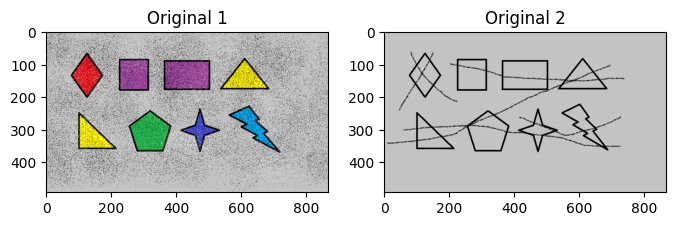

In [2]:
img1 = cv2.imread('IMG/suavizado.png')
img2 = cv2.imread('IMG/suavizado_crayola.png')

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Original 1")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Original 2")

plt.show()

Aplicar diferentes suavizados

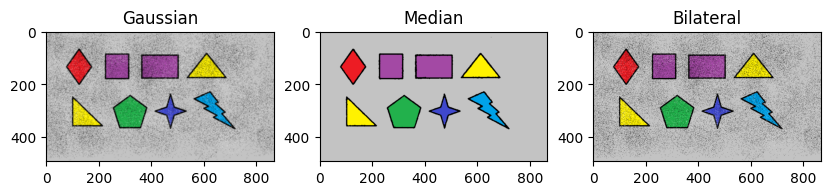

In [3]:
# Imagen 1
blur1 = cv2.GaussianBlur(img1, (5,5), 0)
median1 = cv2.medianBlur(img1, 5)
bilateral1 = cv2.bilateralFilter(img1, 9, 75, 75)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(blur1, cv2.COLOR_BGR2RGB))
plt.title("Gaussian")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(median1, cv2.COLOR_BGR2RGB))
plt.title("Median")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(bilateral1, cv2.COLOR_BGR2RGB))
plt.title("Bilateral")

plt.show()

Suavizado óptimo

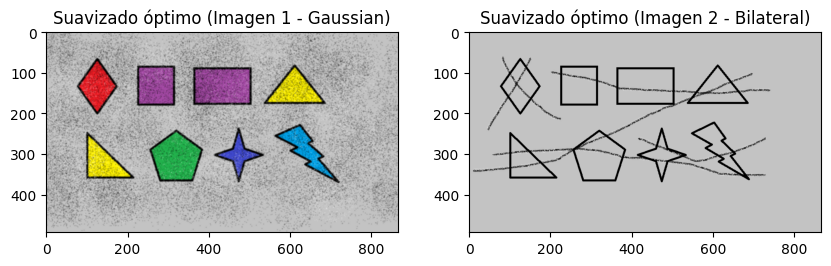

In [4]:
# Imagen 1 → suele funcionar mejor Gaussian (suaviza sin perder tanto detalle)
optimo1 = cv2.GaussianBlur(img1, (5,5), 0)

# Imagen 2 (crayola) → mejor bilateral (mantiene bordes)
optimo2 = cv2.bilateralFilter(img2, 9, 75, 75)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(optimo1, cv2.COLOR_BGR2RGB))
plt.title("Suavizado óptimo (Imagen 1 - Gaussian)")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(optimo2, cv2.COLOR_BGR2RGB))
plt.title("Suavizado óptimo (Imagen 2 - Bilateral)")

plt.show()

RETO 2 — Detectar todos los contornos

cargar imagen

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

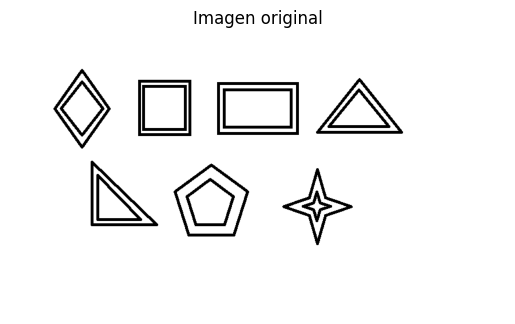

In [5]:
img_contornos = cv2.imread('IMG/contornos.png')

plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis('off')

Procesamiento

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

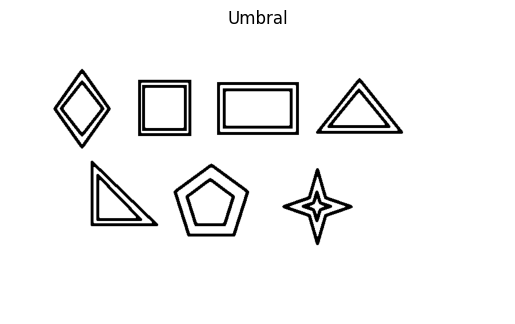

In [6]:
gray = cv2.cvtColor(img_contornos, cv2.COLOR_BGR2GRAY)

# Suavizar
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Umbral
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Umbral")
plt.axis('off')

Contornos

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

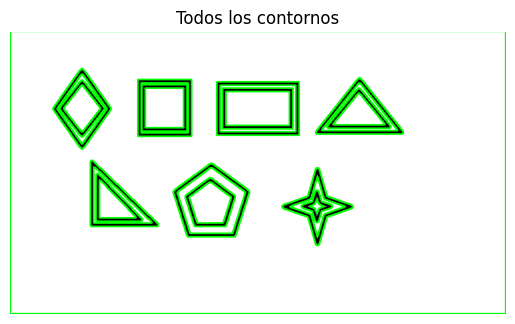

In [7]:
contornos, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar contornos
img_dibujo = img_contornos.copy()

cv2.drawContours(img_dibujo, contornos, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_dibujo, cv2.COLOR_BGR2RGB))
plt.title("Todos los contornos")
plt.axis('off')

RETO 3 — Contornos de imágenes del reto 1

Contornos en suavizado.png

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

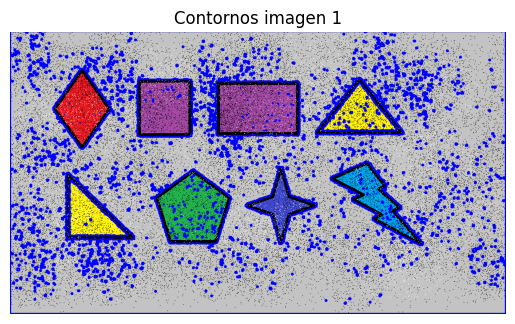

In [8]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
blur1 = cv2.GaussianBlur(gray1, (5,5), 0)

_, thresh1 = cv2.threshold(blur1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contornos1, _ = cv2.findContours(thresh1, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_c1 = img1.copy()
cv2.drawContours(img_c1, contornos1, -1, (255,0,0), 2)

plt.imshow(cv2.cvtColor(img_c1, cv2.COLOR_BGR2RGB))
plt.title("Contornos imagen 1")
plt.axis('off')

Contornos en suavizado_crayola.png

(np.float64(-0.5), np.float64(866.5), np.float64(492.5), np.float64(-0.5))

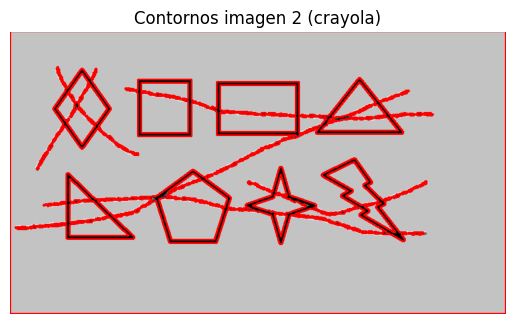

In [9]:
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Mejor usar bilateral aquí
blur2 = cv2.bilateralFilter(gray2, 9, 75, 75)

_, thresh2 = cv2.threshold(blur2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contornos2, _ = cv2.findContours(thresh2, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_c2 = img2.copy()
cv2.drawContours(img_c2, contornos2, -1, (0,0,255), 2)

plt.imshow(cv2.cvtColor(img_c2, cv2.COLOR_BGR2RGB))
plt.title("Contornos imagen 2 (crayola)")
plt.axis('off')